Train: (87554, 187), Test: (21892, 187)
Class distribution (train): Counter({np.int64(0): 72471, np.int64(4): 6431, np.int64(2): 5788, np.int64(1): 2223, np.int64(3): 641})
Class distribution (test): Counter({np.int64(0): 18118, np.int64(4): 1608, np.int64(2): 1448, np.int64(1): 556, np.int64(3): 162})


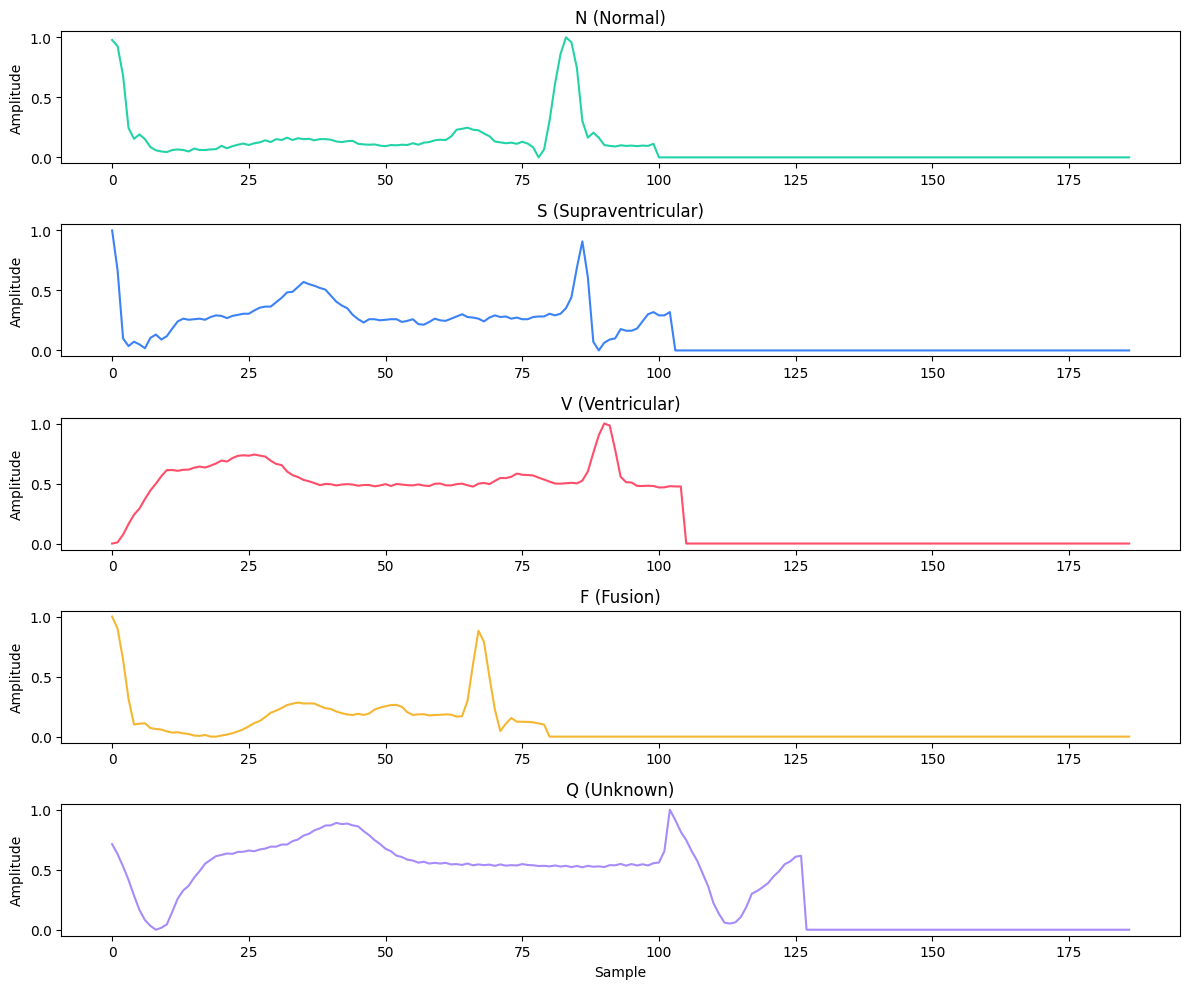

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Load
train = pd.read_csv('data/mitbih_train.csv', header=None)
test = pd.read_csv('data/mitbih_test.csv', header=None)

# Last column is the label
X_train = train.iloc[:, :-1].values
y_train = train.iloc[:, -1].values.astype(int)
X_test = test.iloc[:, :-1].values
y_test = test.iloc[:, -1].values.astype(int)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Class distribution (train): {Counter(y_train)}")
print(f"Class distribution (test): {Counter(y_test)}")

# Plot one beat from each class
class_names = ['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)', 'F (Fusion)', 'Q (Unknown)']
fig, axes = plt.subplots(5, 1, figsize=(12, 10))
for i in range(5):
    idx = np.where(y_train == i)[0][0]
    axes[i].plot(X_train[idx], color=['#22d3a7','#3b82f6','#ff4d6a','#f5b731','#a78bfa'][i])
    axes[i].set_title(class_names[i])
    axes[i].set_ylabel('Amplitude')
axes[4].set_xlabel('Sample')
plt.tight_layout()
plt.savefig('beat_examples.png', dpi=150)
plt.show()

In [2]:
import pandas as pd
stats = []
for c in range(5):
    beats = X_train[y_train == c]
    stats.append({
        'Classe': ['N','S','V','F','Q'][c],
        'Moyenne': beats.mean().round(4),
        'Std': beats.std().round(4),
        'Min': beats.min().round(4),
        'Max': beats.max().round(4),
        'Médiane': np.median(beats).round(4)
    })
pd.DataFrame(stats)

,Classe,Moyenne,Std,Min,Max,Médiane
0,N,0.1619,0.2176,0.0,1.0,0.0743
1,S,0.1948,0.2146,0.0,1.0,0.1471
2,V,0.2438,0.2623,0.0,1.0,0.2108
3,F,0.1073,0.1930,0.0,1.0,0.0000
4,Q,0.2509,0.2643,0.0,1.0,0.1818


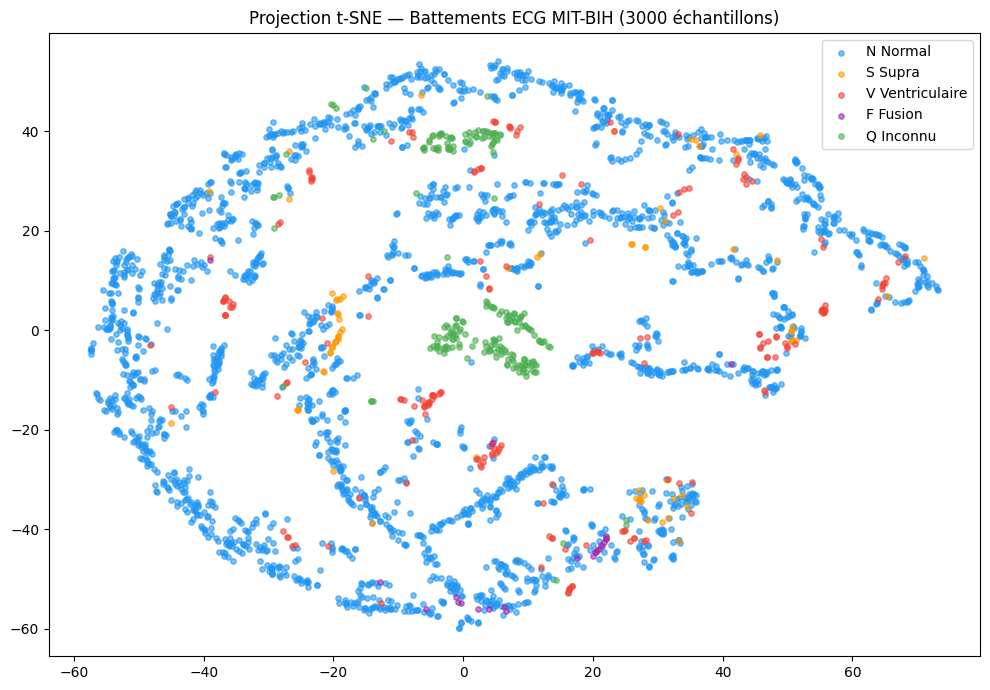

In [4]:
import os
os.makedirs('figures', exist_ok=True)
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Prendre un sous-ensemble pour la vitesse
idx = np.random.choice(len(X_train), 3000, replace=False)
X_sample = X_train[idx].reshape(3000, -1)
y_sample = y_train[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_sample)

colors = ['#2196F3','#FF9800','#F44336','#9C27B0','#4CAF50']
labels = ['N Normal','S Supra','V Ventriculaire','F Fusion','Q Inconnu']
plt.figure(figsize=(10,7))
for i in range(5):
    mask = y_sample == i
    plt.scatter(X_2d[mask,0], X_2d[mask,1],
                c=colors[i], label=labels[i], alpha=0.6, s=15)
plt.legend()
plt.title('Projection t-SNE — Battements ECG MIT-BIH (3000 échantillons)')
plt.tight_layout()
plt.savefig('figures/tsne_mitbih.png', dpi=150)
plt.show()

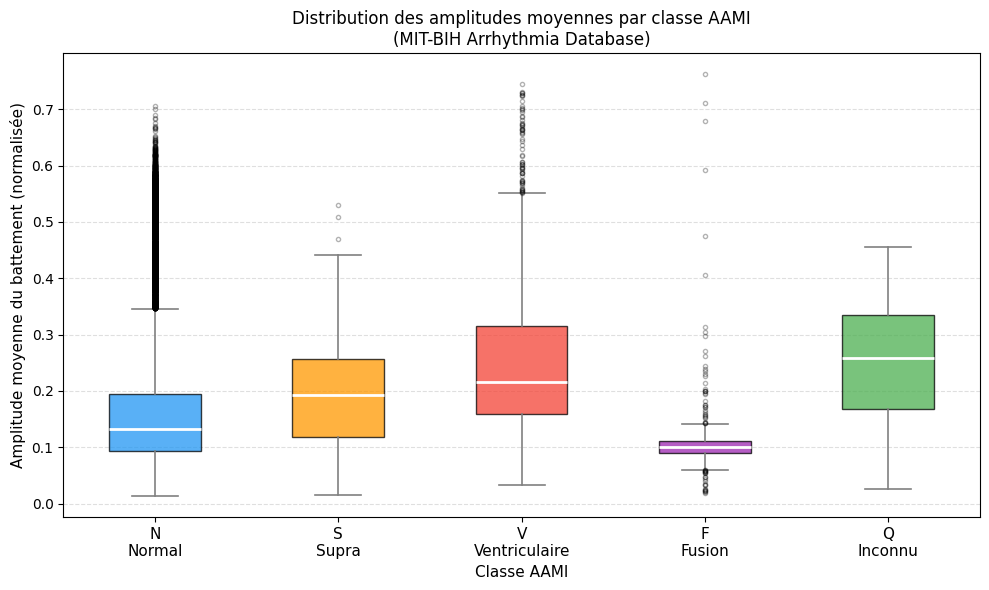

Saved.


In [5]:

import matplotlib.pyplot as plt
import numpy as np

class_names = ['N\nNormal', 'S\nSupra', 'V\nVentriculaire', 'F\nFusion', 'Q\nInconnu']
colors = ['#2196F3', '#FF9800', '#F44336', '#9C27B0', '#4CAF50']

# Amplitude moyenne par battement, par classe
data_per_class = [
    X_train[y_train == i].reshape(-1, 187).mean(axis=1)
    for i in range(5)
]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(data_per_class, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for whisker in bp['whiskers']:
    whisker.set(color='gray', linewidth=1.2)
for cap in bp['caps']:
    cap.set(color='gray', linewidth=1.2)
for flier in bp['fliers']:
    flier.set(marker='o', color='gray', alpha=0.3, markersize=3)

ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylabel('Amplitude moyenne du battement (normalisée)', fontsize=11)
ax.set_title('Distribution des amplitudes moyennes par classe AAMI\n(MIT-BIH Arrhythmia Database)', fontsize=12)
ax.set_xlabel('Classe AAMI', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('figures/boxplot_amplitude_classes.png', dpi=150)
plt.show()
print("Saved.")

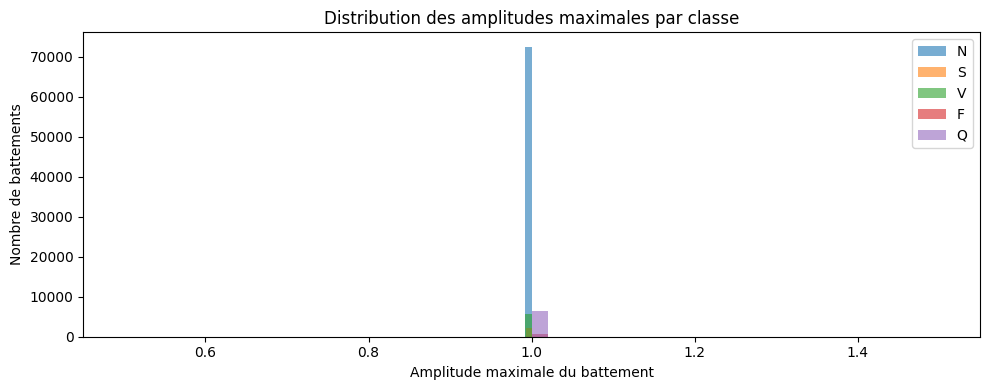

In [6]:
max_amps = X_train.reshape(len(X_train), -1).max(axis=1)
plt.figure(figsize=(10,4))
for i in range(5):
    mask = y_train == i
    plt.hist(max_amps[mask], bins=50, alpha=0.6,
             label=['N','S','V','F','Q'][i])
plt.xlabel('Amplitude maximale du battement')
plt.ylabel('Nombre de battements')
plt.title('Distribution des amplitudes maximales par classe')
plt.legend()
plt.tight_layout()
plt.savefig('figures/outliers_amplitude.png', dpi=150)
plt.show()

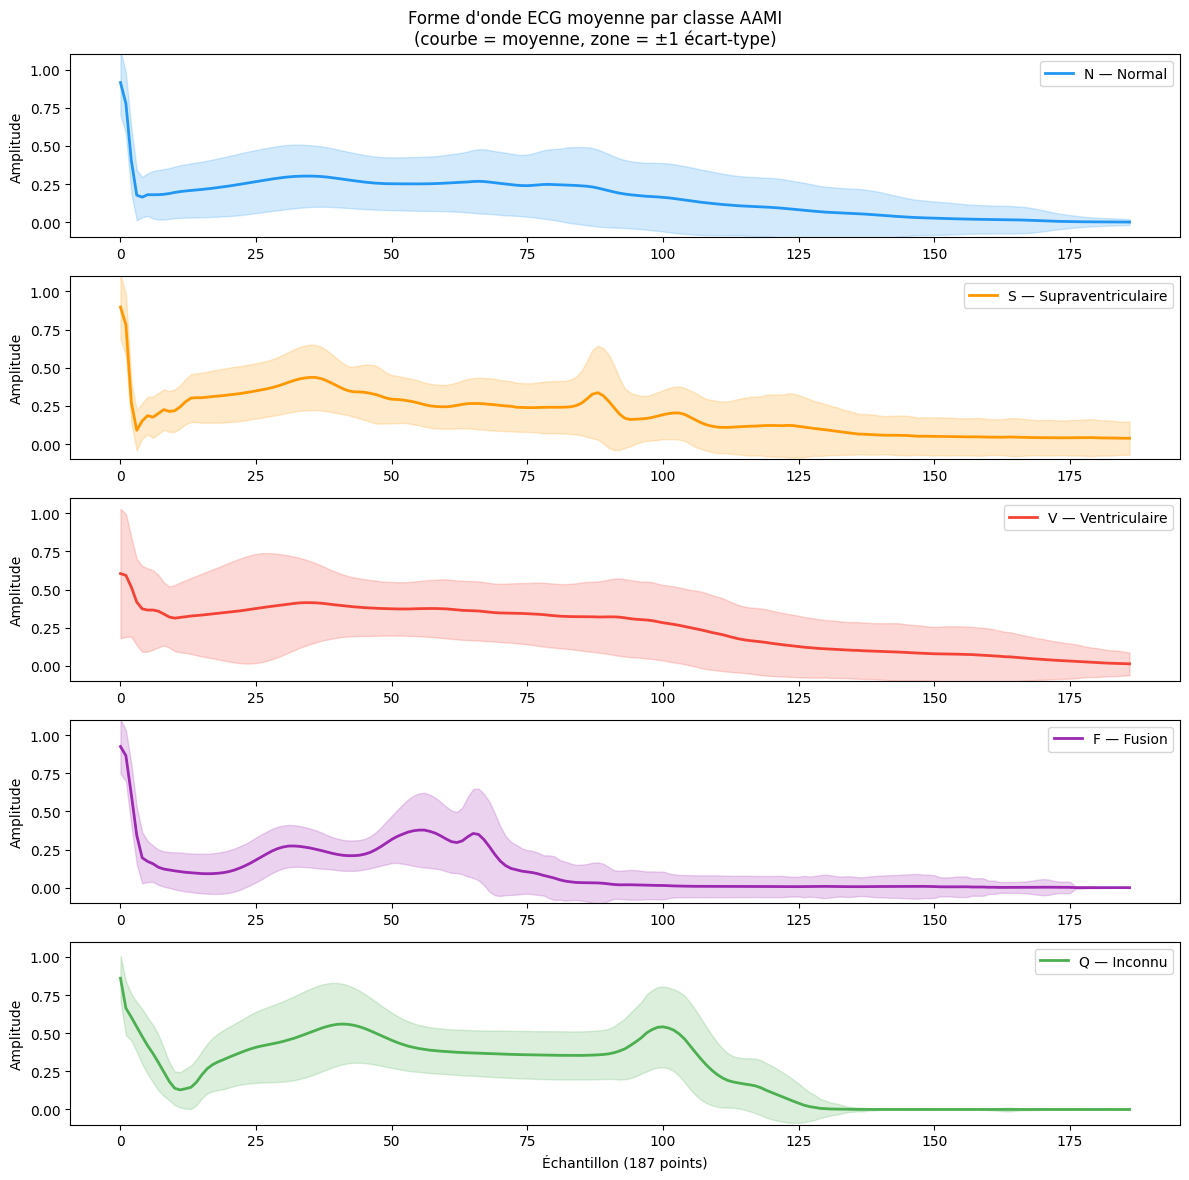

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(12, 12))
colors = ['#2196F3','#FF9800','#F44336','#9C27B0','#4CAF50']
labels = ['N — Normal','S — Supraventriculaire',
          'V — Ventriculaire','F — Fusion','Q — Inconnu']
x = np.arange(187)
for i, ax in enumerate(axes):
    beats = X_train[y_train == i].reshape(-1, 187)
    mean = beats.mean(axis=0)
    std  = beats.std(axis=0)
    ax.plot(x, mean, color=colors[i], linewidth=2, label=labels[i])
    ax.fill_between(x, mean-std, mean+std, alpha=0.2, color=colors[i])
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right')
    ax.set_ylim(-0.1, 1.1)
axes[-1].set_xlabel('Échantillon (187 points)')
plt.suptitle('Forme d\'onde ECG moyenne par classe AAMI\n(courbe = moyenne, zone = ±1 écart-type)')
plt.tight_layout()
plt.savefig('figures/mean_waveforms.png', dpi=150)
plt.show()

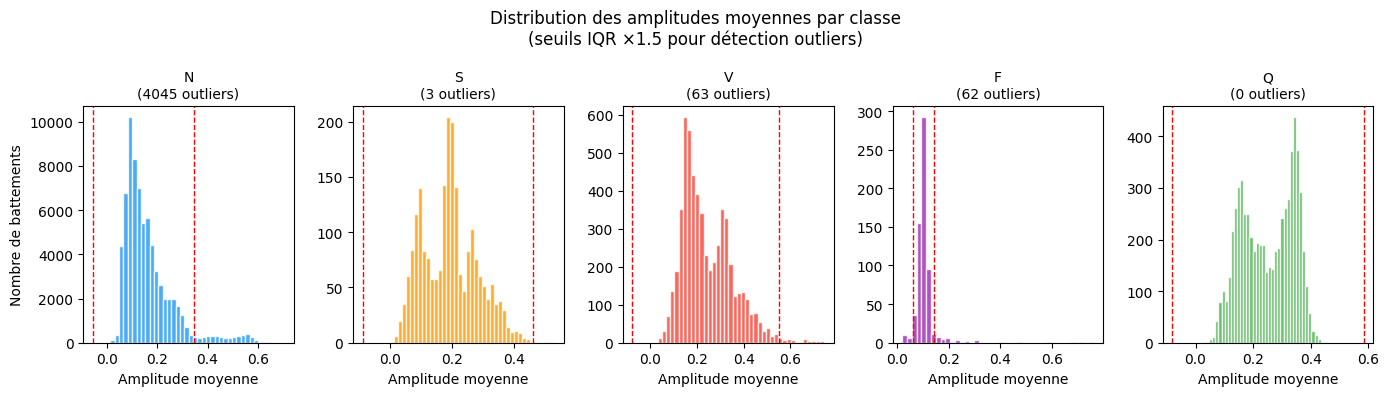

In [8]:

import os
os.makedirs('figures', exist_ok=True)

mean_amps = X_train.reshape(len(X_train), -1).mean(axis=1)
colors = ['#2196F3','#FF9800','#F44336','#9C27B0','#4CAF50']
labels = ['N','S','V','F','Q']

fig, axes = plt.subplots(1, 5, figsize=(14, 4), sharey=False)
for i, ax in enumerate(axes):
    data = mean_amps[y_train == i]
    ax.hist(data, bins=40, color=colors[i], alpha=0.8, edgecolor='white')
    # Ligne IQR pour montrer les outliers
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    ax.axvline(lower, color='red', linestyle='--', linewidth=1, label='Seuil IQR')
    ax.axvline(upper, color='red', linestyle='--', linewidth=1)
    outliers = ((data < lower) | (data > upper)).sum()
    ax.set_title(f'{labels[i]}\n({outliers} outliers)', fontsize=10)
    ax.set_xlabel('Amplitude moyenne')
    if i == 0:
        ax.set_ylabel('Nombre de battements')

plt.suptitle('Distribution des amplitudes moyennes par classe\n(seuils IQR ×1.5 pour détection outliers)',
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/outliers_iqr.png', dpi=150)
plt.show()